# Задача 1

Вы являетесь владельцем сети ресторанов и рассматриваете варианты открытия дополнительных филиалов в других города. Вы заметили закономерность между количеством жителей города и прибылью филиала Вашей сети ресторанов в этом городе.

Файл ex1data1.txt содержит данные о населении города (первый столбец) и прибыли ресторана в нем (второй столбец). Отрицательные значения во втором столбце говорят о том, что в этом городе Ваш бизнес является убыточным. Начнем с того, что посмотрим на эти данные.

Загрузите таблицу с данными из файла ex1data1.txt, посмотрите на них. Для лучшей визуализации постройте точки с соответствующими двумя координатами (Population, Profit) на графике.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv('data/ex1data1.txt', names=['Population', 'Profit'])
data

,Population,Profit
0,6.1101,17.59200
1,5.5277,9.13020
2,8.5186,13.66200
3,7.0032,11.85400
4,5.8598,6.82330
...,...,...
92,5.8707,7.20290
93,5.3054,1.98690
94,8.2934,0.14454
95,13.3940,9.05510


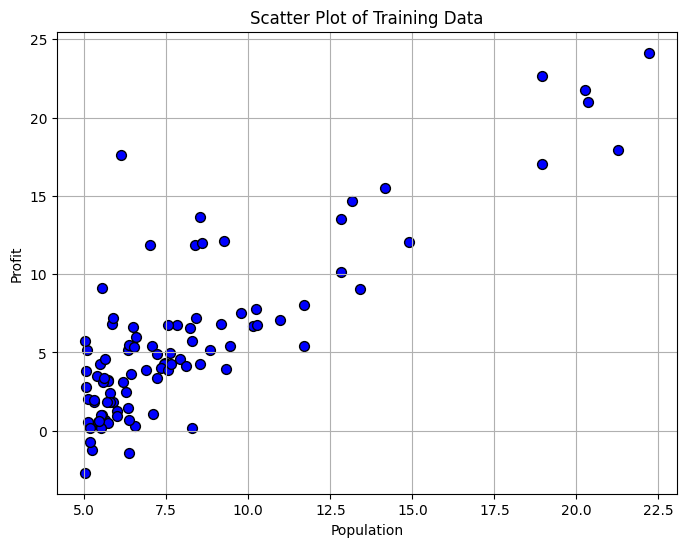

In [2]:
# Первый столбец - Population (x), второй - Profit (y)
X = data['Population']
y = data['Profit']

# Визуализация данных: scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', marker='o', edgecolor='black', s=50)
plt.xlabel('Population')
plt.ylabel('Profit')
plt.title('Scatter Plot of Training Data')
plt.grid(True)
plt.show()

Реализуйте функцию `computeCost(X, y, theta)`, вычисляющую значение целевой функции $J(\theta)$ по формуле

$$
J(\theta) = \frac{(X\theta - Y)^\mathrm{T}(X\theta - Y)}{2m}
$$

Найдите её значение при $\theta_0 = 0, \theta_1 = 0$. Проверьте, что оно равно $32.07$.

In [3]:
# noinspection PyShadowingNames
def computeCost(X: np.matrix, y: np.matrix, theta: np.matrix) -> float:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    j = X @ theta - y
    return (j.T @ j).item() / (2 * len(y))

In [4]:
X = np.column_stack([np.ones(len(data)), data['Population']])
y: np.matrix = data['Profit'].values
theta: np.matrix = np.zeros(shape=(2, 1))

# Compute cost
result: float = computeCost(X=X, y=y, theta=theta)
print(f'result = {result}')

result = 32.072733877455676


Используя формулу реализуйте функцию `gradientDescent(X, y, theta, alpha, iters)`, возвращающую новые значения параметров $\theta_0$, $\theta_1$ и массив с `iters` значениями целевой функции на каждой итерации.

$$
\theta^{\text{new}} = \theta^{\text{old}} - \frac{\alpha}{m} \cdot X^{\mathrm{T}} \cdot (X\theta - Y)
$$

Для проверки её работы убедитесь, что для $\alpha = 0.01$ и $iters = 1000$ и нулевых начальных значениях $\theta_0$, $\theta_1$ у вас получаются новые значения параметров
$\theta_0 = -3.24$, $\theta_1 = 1.13$.

Вычислите значение целевой функции для новых значений параметров. Стало ли оно меньше, чем $32.07$?

In [5]:
from typing import Tuple, List


# noinspection PyShadowingNames
def gradientDescent(X: np.matrix, y: np.matrix, theta: np.matrix, alpha: float, iters: int) -> Tuple[np.matrix, List[float]]:
    iters_history: List[float] = list()
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    for i in range(iters):
        theta = theta - (alpha / len(y)) * X.T @ (X @ theta - y)
        iters_history.append(computeCost(X=X, y=y, theta=theta))
    return theta, iters_history

In [6]:
X = np.column_stack([np.ones(len(data)), data['Population']])
y: np.matrix = data['Profit'].values
theta: np.matrix = np.zeros(shape=(2, 1))
alpha: float = 0.01
iters: int = 1000

# Process new theta and iters history
new_theta, iters_history = gradientDescent(X=X, y=y, theta=theta, alpha=alpha, iters=iters)
print(f'new_theta = {new_theta[0].item(), new_theta[1].item()}')
print(f'J(new_theta) = {iters_history[-1]}')

new_theta = (-3.241402144274422, 1.1272942024281842)
J(new_theta) = 4.515955503078914


Постройте график с точками (Population, Profit), как в начале этой работы и добавьте к нему прямую $h(x) = \theta_0 + \theta_1 x$ с найденными значениями параметров. Что Вы можете сказать о полученном рисунке?

Постройте график зависимости значений целевой функции от числа итераций и убедитесь, что Вы получили убывающую кривую.

In [7]:
# noinspection PyTypeChecker, PyShadowingNames
def predict(X: np.matrix, theta: np.matrix) -> np.matrix:
    return X @ theta

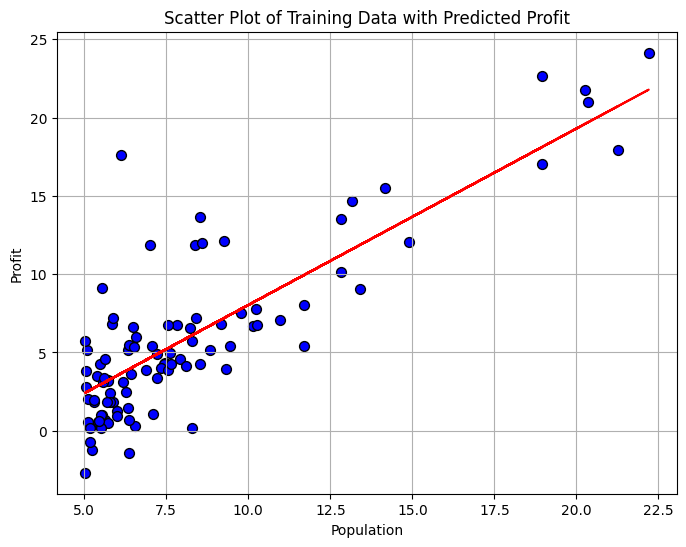

In [8]:
# Первый столбец - Population (x), второй - Profit (y)
X = data['Population']
y = data['Profit']
X_vector = np.column_stack([np.ones(len(data)), X])

# Визуализация данных: scatter plot + linear plot
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', marker='o', edgecolor='black', s=50)
plt.plot(X, predict(X=X_vector, theta=new_theta), color='red')
plt.xlabel('Population')
plt.ylabel('Profit')
plt.title('Scatter Plot of Training Data with Predicted Profit')
plt.grid(True)
plt.show()

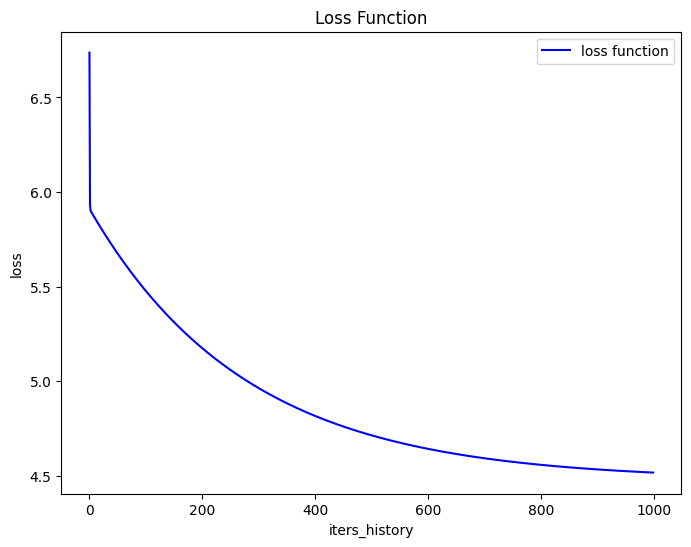

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0, iters), iters_history, label='loss function', color='blue')
plt.title('Loss Function')
plt.xlabel('iters_history')
plt.ylabel('loss')
plt.legend()
plt.show()

Повторите решение задачи при $\alpha = 0.05, \alpha = 0.001$. Объясните полученные результаты.

Что изменилось на графике со значениями целевой функции и почему? Как быстро они уменьшаются?

In [10]:
X = np.column_stack([np.ones(len(data)), data['Population']])
y: np.matrix = data['Profit'].values
theta: np.matrix = np.zeros(shape=(2, 1))
alpha: float = 0.05
iters: int = 1000

# Process new theta and iters history
new_theta, iters_history = gradientDescent(X=X, y=y, theta=theta, alpha=alpha, iters=iters) # Произошло переполнение из-за слишком большого шага
print(f'new_theta = {new_theta[0].item(), new_theta[1].item()}')
print(f'J(new_theta) = {iters_history[-1]}')

new_theta = (nan, nan)
J(new_theta) = nan


/tmp/ipykernel_43890/1987990921.py:6: RuntimeWarning: overflow encountered in matmul
  return (j.T @ j).item() / (2 * len(y))
/tmp/ipykernel_43890/1987990921.py:5: RuntimeWarning: overflow encountered in matmul
  j = X @ theta - y
/tmp/ipykernel_43890/246140465.py:10: RuntimeWarning: overflow encountered in matmul
  theta = theta - (alpha / len(y)) * X.T @ (X @ theta - y)
/tmp/ipykernel_43890/246140465.py:10: RuntimeWarning: invalid value encountered in subtract
  theta = theta - (alpha / len(y)) * X.T @ (X @ theta - y)


new_theta = (-0.5760702125335738, 0.8595326995131465)
J(new_theta) = 5.480269332020323


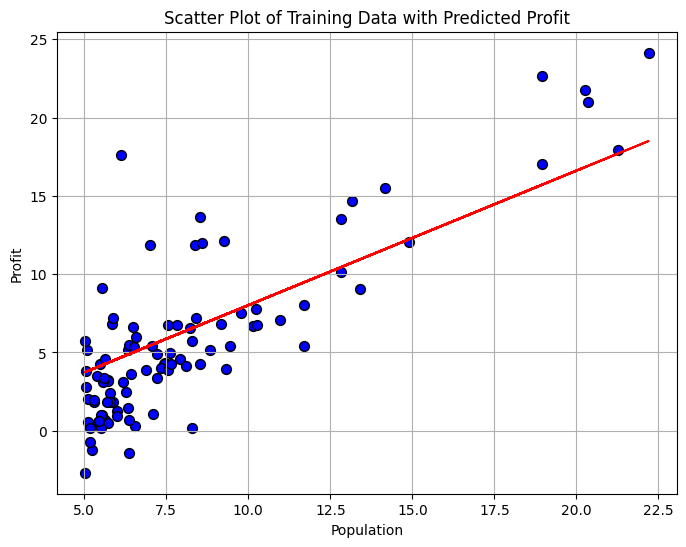

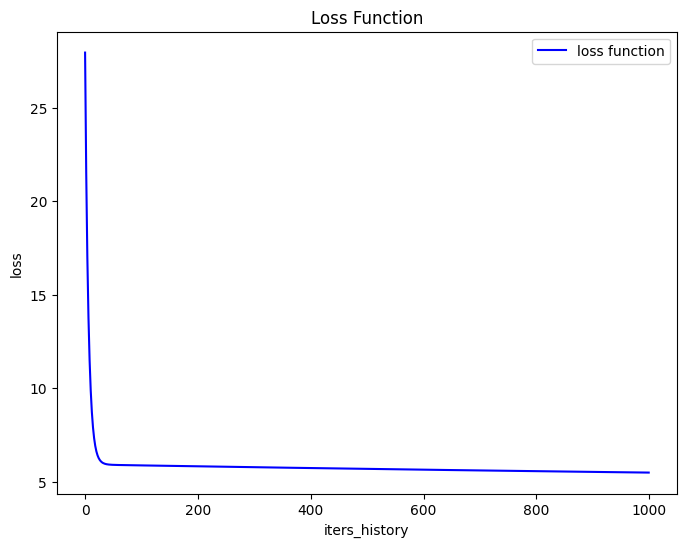

In [11]:
X = np.column_stack([np.ones(len(data)), data['Population']])
y: np.matrix = data['Profit'].values
theta: np.matrix = np.zeros(shape=(2, 1))
alpha: float = 0.001
iters: int = 1000

# Process new theta and iters history
new_theta, iters_history = gradientDescent(X=X, y=y, theta=theta, alpha=alpha, iters=iters)
# Значение J(theta) стало больше, при этом сами theta стали более приближенные к нулю (theta0 стала больше, theta1 стала меньше)
print(f'new_theta = {new_theta[0].item(), new_theta[1].item()}')
print(f'J(new_theta) = {iters_history[-1]}')

# Первый столбец - Population (x), второй - Profit (y)
X = data['Population']
y = data['Profit']
X_vector = np.column_stack([np.ones(len(data)), X])

# Визуализация данных: scatter plot + linear plot
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', marker='o', edgecolor='black', s=50)
plt.plot(X, predict(X=X_vector, theta=new_theta), color='red')
plt.xlabel('Population')
plt.ylabel('Profit')
plt.title('Scatter Plot of Training Data with Predicted Profit')
plt.grid(True)
plt.show()
# По графику можно увидеть, что полученная функция линейной регрессии стала хуже предсказывать как небольшие значения, так и большие

# Визуализация функции потерь
plt.show()
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0, iters), iters_history, label='loss function', color='blue')
plt.title('Loss Function')
plt.xlabel('iters_history')
plt.ylabel('loss')
plt.legend()
plt.show()

# Считаем сами

In [12]:
print(f'Для населения 10млн: {predict(np.array([[1, 10]]), new_theta).item()}')

Для населения 10млн: 8.01925678259789
